# RAPID-MFA 18a: Trouble shooting: negative inflows from jittery stock

# Descriptions

This variant of the stock driven model shows how to troubleshoot in case the stocks in the time series exhibit jittery behavior. Typically, stocks' time series data are relatively smooth, as stocks of products, goods, and materials tend to change minimally between consecutive periods. However, at times, the stocks' time series data may display abrupt jumps, dips, jolts, and jitters, such as:

- A significant portion of stock is removed within a single period, potentially due to a disaster or new regulation.
- A new product rapidly gains popularity, significantly impacting the market.
- Changes in measurement methodologies occur during the time series, or data is released in long intervals.

The dynamic MFA model does not effectively handle jittery stocks data, as it cannot replicate sudden outflows associated with such fluctuations (although it models sudden inflows very well). Therefore, the unaccounted outflows are often propagated as negative inflows through the principle of mass balance.

This example shows inflows being nearly identical to the stock_changes, which on its own is not an issue (as would be the case if inflows are mainly used for maintenance); however, this does become an issue when the stock_changes are negative, and there are insufficient outflows, making the inflows negative. 

We troubleshoot by smoothing the stocks using a rolling average, which allows to keep the general trends of the data so that the dynamic MFA model can be calculated. 

### Exogenous variables
__Stock:__ Steel in railroads of Japan from _Tanikawa, H., Fishman, T., Okuoka, K., & Sugimoto, K. (2015). The weight of society over time and space: A comprehensive account of the construction material stock of Japan, 1945–2010. Journal of Industrial Ecology, 19(5), 778-791._

__Survival curve:__ mock values. 

### Notes
1. This example uses Normal distribution survival curves, but they can be replaced with any other curves.
2. This code uses a 15-year rolling average for smoothing the stock, but it can be adjusted to best fit the data. 
3. By smoothing the stocks we must question the representativeness of the historical stocks, and how this trade-off affects our results.

### Relations with other RAPID-MFA codes
- `RAPID-MFA-2: The stock driven model`: The modelling steps are following those in this notebook.
- `RAPID-MFA-18b: Trouble shooting: negative inflows missing initial stocks`: is an alternative solution to the jittery stocks issue.

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

## 1. Load libraries

In [18]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

## 2. Define example input data

In [19]:
# %% 2. Define example input data
input_data = pd.Series([0, 1589.92044238839, 4174.97379636625, 6341.17016937677, 7057.72612072993, 14197.6653813324, 
                        15172.4906177958, 22248.8630269975, 30216.313536339, 19904.1159720295, 24195.1630586581, 26111.4967549224, 
                        15956.5069599557, 24422.9893887052, 151234.417155242, 143954.599989763, 141319.680460439, 128616.529901319, 
                        120716.908176351, 105185.288345919, 102941.451955893, 85200.2580356868, 102154.187509496, 119973.029369821, 
                        130757.169645763, 219101.289758638, 220403.506565163, 226363.678542011, 230524.471354418, 234352.61055297, 
                        237063.59447982, 249671.709501674, 430679.847602303, 430679.847602303, 428894.722800646, 420526.665806541, 
                        403736.198190414, 330377.901233864, 359175.996638114, 319164.066264116, 324028.350336052, 331084.548437878, 
                        329015.71402006, 330566.394879809, 339150.079441408, 328227.124630001, 336348.727907291, 379633.096199615, 
                        384631.794563517, 388662.061157363, 396300.888202171, 395141.275063793, 415535.395798969, 413141.411499053, 
                        433632.548771695, 441013.94783848, 431388.253633382, 422767.630262156, 425626.462275018, 426560.478406911, 
                        450526.43531986, 483049.57208926], 
                        name = 'stocks', 
                        index = [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 
                                 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 
                                 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 
                                 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 
                                 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 
                                 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
                                 2010, 2011]) 

# Parameters for the survival curve
ages = range(0, len(input_data)) 
mean = 30
std_dev = 10

# create the survival curve
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)

## 3. Run the stock-driven model

The steps from hereon are a repetition of notebook 2, but with different input data. If you want a more detailed account on how to do this, see notebook 2.

In [20]:
# %% 3. Run the stock-driven model
units = {'time_interval':   'year', 
         'flows':           'tonnes/year', 
         'stocks':          'tonnes'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.
time_interval = 1
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required
mfa_system = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system['stocks'] = input_data

# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
   
# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system.loc[cohort, 'inflows'] = (
        mfa_system.loc[cohort, 'stocks'] - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, 'inflows']
    
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

## 4. Identify the jittery stock and negative inflow issues

<Axes: ylabel='tonnes'>

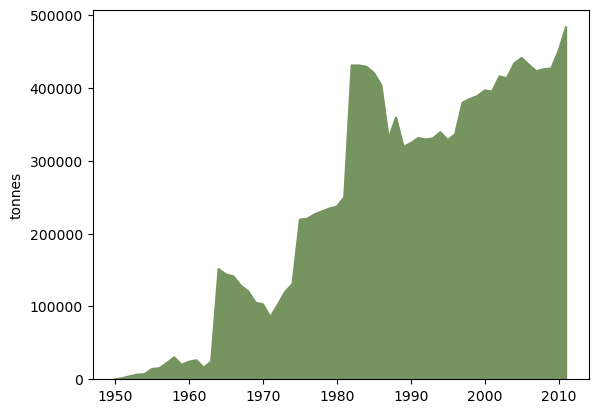

In [21]:
# Visualize the results of the MFA system
mfa_system["stocks"].plot(kind="area", ylabel=units["stocks"], color="#759460")

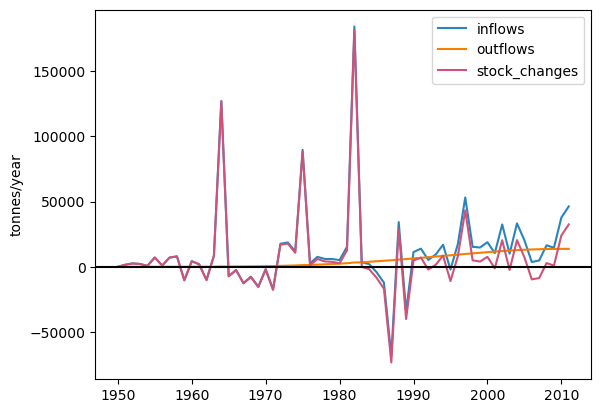

In [22]:
mfa_system[['inflows', 'outflows', 'stock_changes']].plot(ylabel=units["flows"],
                                                                color=["#2985BD", "#F67E00", "#D15278"])
plt.axhline(0, color='black') 

<Axes: ylabel='tonnes'>

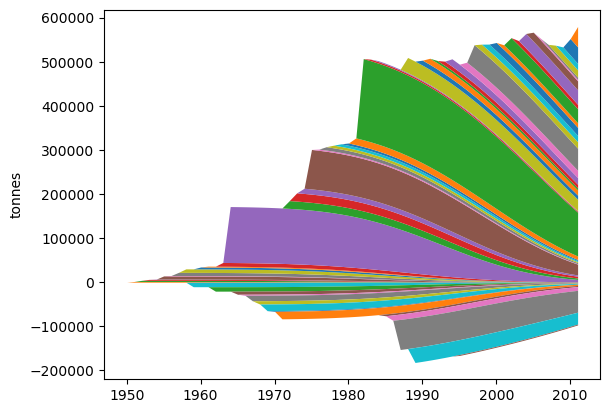

In [23]:
cohorts_survival_matrix.plot(kind="area", legend=False, ylabel=units['stocks'], linewidth=0)

## 5. Solve the negative inflows by smoothing the stocks over time

<Axes: ylabel='tonnes'>

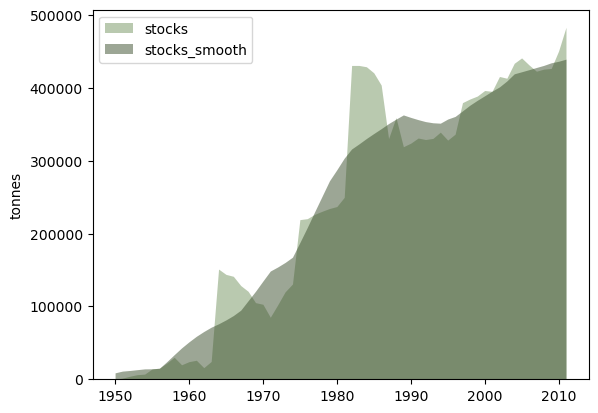

In [24]:
# Smoothing the stocks using a 15-year rolling mean to reduce jitteriness

mfa_system["stocks_smooth"] = mfa_system["stocks"].rolling(15, center=True, min_periods=1).mean()
mfa_system[['stocks', 'stocks_smooth']].plot(color=["#759460", "#3B4F2D"], kind='area', stacked=False, ylabel=units['stocks'], linewidth=0)

In [ ]:
# Recalculate the MFA model with the new survival curve
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system.loc[cohort, 'inflows'] = (
        mfa_system.loc[cohort, 'stocks_smooth'] - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix.loc[cohort, cohort]
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, 'inflows']

mfa_system["stock_changes"] = np.diff(mfa_system["stocks_smooth"], prepend=0)
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

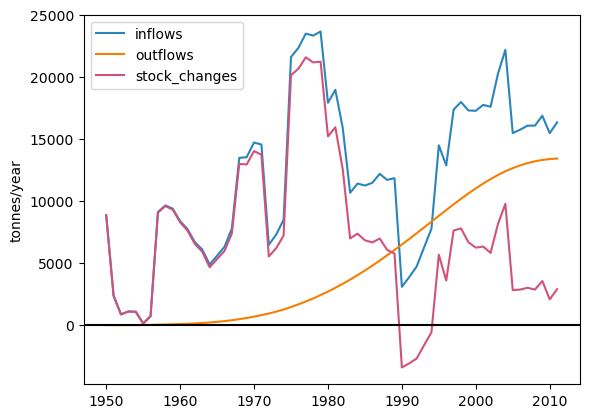

In [26]:
# Visualize the new MFA model
mfa_system[['inflows', 'outflows', 'stock_changes']].plot(ylabel=units["flows"],
                                                                color=["#2985BD", "#F67E00", "#D15278"])
plt.axhline(0, color='black') 

<Axes: ylabel='tonnes'>

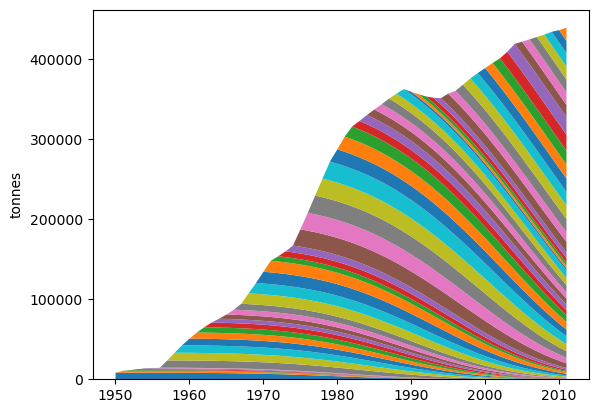

In [27]:
cohorts_survival_matrix.plot(kind="area", legend=False, ylabel=units['stocks'], linewidth=0)